In [26]:
new_customer = pd.DataFrame({
    "Age": [32],
    "Income": [45000],
    "LoanAmount": [12000],
    "CreditScore": [700],
    "LoanTerm": [24],
    "Employment": [0]
})

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Prediction: Loan Default Risk")
else:
    print("Prediction: Low Default Risk")

Prediction: Low Default Risk


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("dataset.csv")

df.head()

,Age,Income,LoanAmount,CreditScore,LoanTerm,Employment,Default
0,25,30000,5000,650,12,Salaried,No
1,35,50000,15000,720,24,Salaried,No
2,45,25000,20000,580,36,Self,Yes
3,29,40000,10000,690,12,Salaried,No
4,52,20000,25000,540,48,Self,Yes


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (20, 7)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          20 non-null     int64
 1   Income       20 non-null     int64
 2   LoanAmount   20 non-null     int64
 3   CreditScore  20 non-null     int64
 4   LoanTerm     20 non-null     int64
 5   Employment   20 non-null     str  
 6   Default      20 non-null     str  
dtypes: int64(5), str(2)
memory usage: 1.2 KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age            0
Income         0
LoanAmount     0
CreditScore    0
LoanTerm       0
Employment     0
Default        0
dtype: int64


In [6]:
df = pd.read_csv("dataset.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,LoanTerm,Employment,Default
0,25,30000,5000,650,12,Salaried,No
1,35,50000,15000,720,24,Salaried,No
2,45,25000,20000,580,36,Self,Yes
3,29,40000,10000,690,12,Salaried,No
4,52,20000,25000,540,48,Self,Yes


In [7]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (20, 7)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          20 non-null     int64
 1   Income       20 non-null     int64
 2   LoanAmount   20 non-null     int64
 3   CreditScore  20 non-null     int64
 4   LoanTerm     20 non-null     int64
 5   Employment   20 non-null     str  
 6   Default      20 non-null     str  
dtypes: int64(5), str(2)
memory usage: 1.2 KB


In [8]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Age            0
Income         0
LoanAmount     0
CreditScore    0
LoanTerm       0
Employment     0
Default        0
dtype: int64


In [9]:
print("Dataset Shape:", df.shape)

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (20, 7)

Statistical Summary:
             Age        Income   LoanAmount  CreditScore   LoanTerm
count  20.000000     20.000000     20.00000    20.000000  20.000000
mean   38.300000  38650.000000  16550.00000   648.000000  27.300000
std     8.956621  12811.487444   7044.78157    75.714144  14.235242
min    25.000000  20000.000000   5000.00000   520.000000  12.000000
25%    30.750000  27750.000000  10750.00000   577.500000  12.000000
50%    37.000000  37500.000000  15500.00000   665.000000  24.000000
75%    45.250000  48500.000000  21250.00000   712.500000  36.000000
max    55.000000  60000.000000  30000.00000   750.000000  60.000000


In [10]:
print(df["Default"].value_counts())

Default
No     12
Yes     8
Name: count, dtype: int64


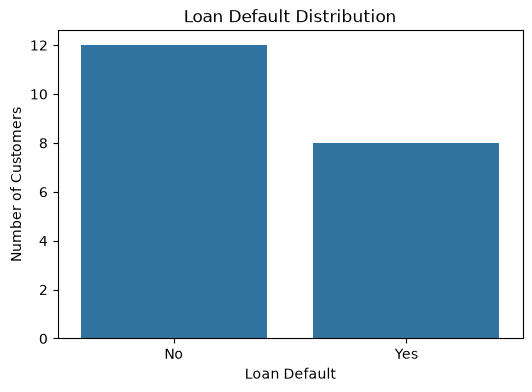

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Default", data=df)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Default")
plt.ylabel("Number of Customers")

plt.show()

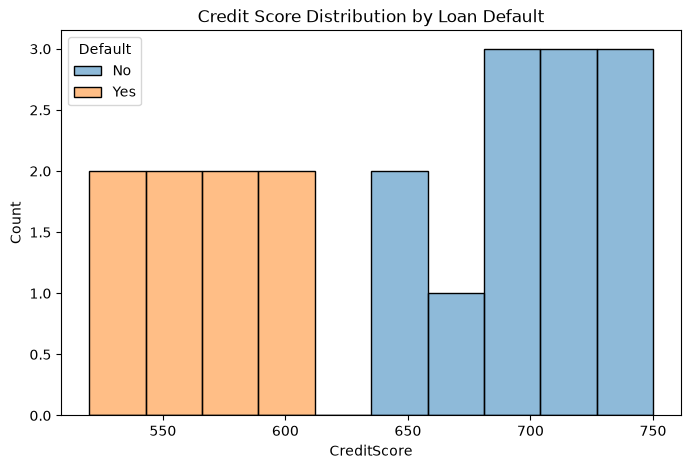

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="CreditScore",
    hue="Default",
    bins=10
)

plt.title("Credit Score Distribution by Loan Default")

plt.show()

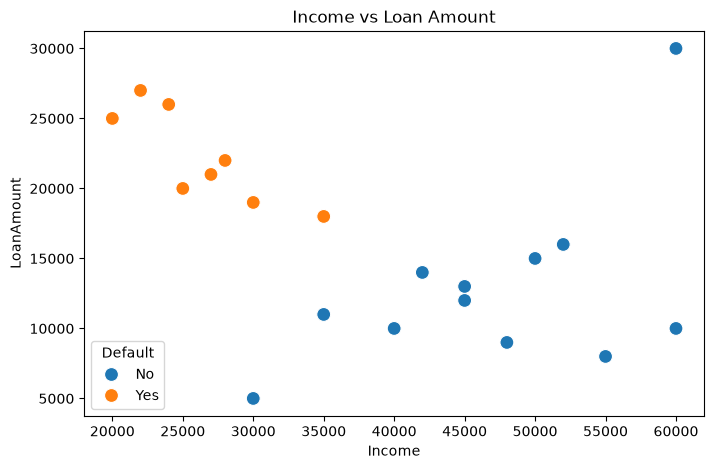

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Income",
    y="LoanAmount",
    hue="Default",
    s=100
)

plt.title("Income vs Loan Amount")

plt.show()

In [14]:
# Convert categorical columns into numbers

encoder = LabelEncoder()

df["Employment"] = encoder.fit_transform(df["Employment"])
df["Default"] = encoder.fit_transform(df["Default"])

print("Categorical data converted successfully!")
print(df.head())

Categorical data converted successfully!
   Age  Income  LoanAmount  CreditScore  LoanTerm  Employment  Default
0   25   30000        5000          650        12           0        0
1   35   50000       15000          720        24           0        0
2   45   25000       20000          580        36           1        1
3   29   40000       10000          690        12           0        0
4   52   20000       25000          540        48           1        1


In [15]:
# Input features
X = df.drop("Default", axis=1)

# Target variable
y = df["Default"]

print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("Default")

Input Features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'LoanTerm', 'Employment']

Target Variable:
Default


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16, 6)
Testing Data: (4, 6)


In [17]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [18]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[0 1 0 0]


In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 75.0 %


In [20]:
print("Classification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=["No Default", "Default"]
))

Classification Report:

              precision    recall  f1-score   support

  No Default       0.67      1.00      0.80         2
     Default       1.00      0.50      0.67         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



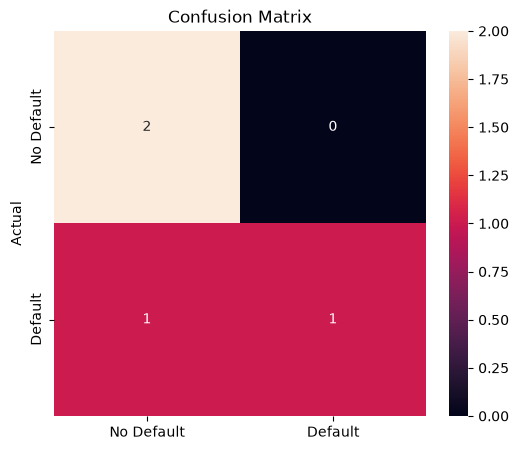

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)

plt.title("Confusion Matrix")
plt.ylabel("Actual")

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

print(feature_importance)

Age            0.22
CreditScore    0.19
LoanTerm       0.18
Employment     0.16
LoanAmount     0.15
Income         0.10
dtype: float64


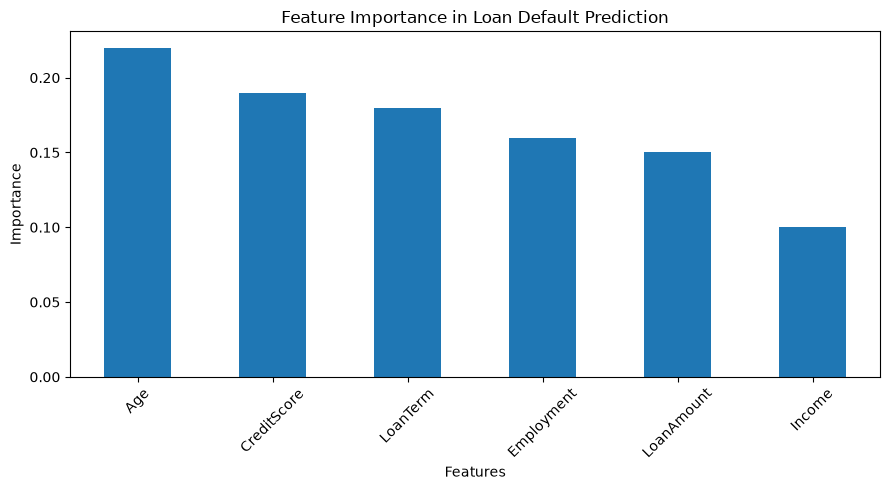

In [28]:
plt.figure(figsize=(9, 5))

feature_importance.plot(kind="bar")

plt.title("Feature Importance in Loan Default Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [24]:
new_customer = pd.DataFrame({
    "Age": [32],
    "Income": [45000],
    "LoanAmount": [12000],
    "CreditScore": [700],
    "LoanTerm": [24],
    "Employment": [0]
})

prediction = model.predict(new_customer)

if prediction[0] == 1:
    print("Prediction: Loan Default Risk")
else:
    print("Prediction: Low Default Risk")

Prediction: Low Default Risk
